In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing The Training Dataset 
house_prices = pd.read_csv("train.csv")

print("House prices dataset shape:", house_prices.shape)
house_prices.head()

House prices dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### The dataset has 1460 rows and 81 columns. 

In [82]:
# Isolating Selected Variables

selected_variables = ["KitchenQual","BedroomAbvGr","YearBuilt","YearRemodAdd","OverallQual",
"1stFlrSF","2ndFlrSF","FullBath","HalfBath","TotalBsmtSF"]

# Create an independent copy
house_prices_data = house_prices[selected_variables].copy()

# Variable feature engineering
house_prices_data["HouseAgeAtSale"] = (house_prices["YrSold"] - house_prices["YearBuilt"])

# Remove YearBuilt because HouseAgeAtSale replaces it
house_prices_data = house_prices_data.drop(columns=["YearBuilt"])

house_prices_data.head()

,KitchenQual,BedroomAbvGr,YearRemodAdd,OverallQual,1stFlrSF,2ndFlrSF,FullBath,HalfBath,TotalBsmtSF,HouseAgeAtSale
0,Gd,3,2003,7,856,854,2,1,856,5
1,TA,3,1976,6,1262,0,2,0,1262,31
2,Gd,3,2002,7,920,866,2,1,920,7
3,Gd,3,1970,7,961,756,1,0,756,91
4,Gd,4,2000,8,1145,1053,2,1,1145,8


In [83]:
# Overview Of The Selected Variables 

print("Dataset Information")
house_prices_data.info()

print("Dataset Summary Statistics")
display(house_prices_data.describe(include="all").T)

print("Dataset Missing Values")
display(house_prices_data.isnull().sum())

print("Dataset Duplicate Rows")
print(house_prices_data.duplicated().sum())

print("Dataset Unique Values")
display(house_prices_data.nunique())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   KitchenQual     1460 non-null   object
 1   BedroomAbvGr    1460 non-null   int64 
 2   YearRemodAdd    1460 non-null   int64 
 3   OverallQual     1460 non-null   int64 
 4   1stFlrSF        1460 non-null   int64 
 5   2ndFlrSF        1460 non-null   int64 
 6   FullBath        1460 non-null   int64 
 7   HalfBath        1460 non-null   int64 
 8   TotalBsmtSF     1460 non-null   int64 
 9   HouseAgeAtSale  1460 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 114.2+ KB
Dataset Summary Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
KitchenQual,1460,4,TA,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BedroomAbvGr,1460.0,NaN,NaN,NaN,2.866438,0.815778,0.0,2.0,3.0,3.0,8.0
YearRemodAdd,1460.0,NaN,NaN,NaN,1984.865753,20.645407,1950.0,1967.0,1994.0,2004.0,2010.0
OverallQual,1460.0,NaN,NaN,NaN,6.099315,1.382997,1.0,5.0,6.0,7.0,10.0
1stFlrSF,1460.0,NaN,NaN,NaN,1162.626712,386.587738,334.0,882.0,1087.0,1391.25,4692.0
2ndFlrSF,1460.0,NaN,NaN,NaN,346.992466,436.528436,0.0,0.0,0.0,728.0,2065.0
FullBath,1460.0,NaN,NaN,NaN,1.565068,0.550916,0.0,1.0,2.0,2.0,3.0
HalfBath,1460.0,NaN,NaN,NaN,0.382877,0.502885,0.0,0.0,0.0,1.0,2.0
TotalBsmtSF,1460.0,NaN,NaN,NaN,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
HouseAgeAtSale,1460.0,NaN,NaN,NaN,36.547945,30.250152,0.0,8.0,35.0,54.0,136.0


Dataset Missing Values


KitchenQual       0
BedroomAbvGr      0
YearRemodAdd      0
OverallQual       0
1stFlrSF          0
2ndFlrSF          0
FullBath          0
HalfBath          0
TotalBsmtSF       0
HouseAgeAtSale    0
dtype: int64

Dataset Duplicate Rows
11
Dataset Unique Values


KitchenQual         4
BedroomAbvGr        8
YearRemodAdd       61
OverallQual        10
1stFlrSF          753
2ndFlrSF          417
FullBath            4
HalfBath            3
TotalBsmtSF       721
HouseAgeAtSale    122
dtype: int64

### Of the 10 selected variables, one is an object variable and nine are integer variables. 

### There are no missing values within the variables selected. 

### There are 11 repeated predictor profiles. These should not be removed because different houses may share the same kitchen quality, room counts, quality rating, age, and square-footage measurements.

### The variables related to square footage have the most unique values, followed by House Age At Sale, Year Remodeled, Overall Quality, Bedroom Above Ground, followed by Kitchen Quality, Full Bath, and Half Bath.

### Within the dataset, of the selected variables, the mean Bedrooms Above Ground is 2.87 bedrooms. The mean House Age At Sale is 36.55 years old. The mean Year Remodeled is 1984.87. The mean  Overall Quality is 6.10, which translates to 'Above Average.' The mean 1st Floor Square Footage is 1,162.63 square feet. The mean 2nd Floor Square Footage is 346.99 square feet. The mean Full Bath is 1.57 bathrooms. The mean Half Bath is 0.38. The mean Total Basement Square Footage is 1,057.43 square feet. 

In [84]:
# Creating Categorical Target

house_prices_bins = [0,100000,150000,200000, np.inf]

house_prices_labels = ["Under 100k","100k-149,999","150k-199,999","200k+"]

house_prices_data["SalePriceCategory"] = pd.cut(house_prices["SalePrice"],
                                                bins=house_prices_bins,
                                                labels=house_prices_labels,
                                                right=False, 
                                                include_lowest=True)
print("Missing price categories:")
print(house_prices_data["SalePriceCategory"].isnull().sum())

print("Price category counts:")
print(house_prices_data["SalePriceCategory"].value_counts(sort=False))

print("Price category percentages:")
print(house_prices_data["SalePriceCategory"].value_counts(
    normalize=True,sort=False).mul(100).round(1))

Missing price categories:
0
Price category counts:
SalePriceCategory
Under 100k      114
100k-149,999    501
150k-199,999    410
200k+           435
Name: count, dtype: int64
Price category percentages:
SalePriceCategory
Under 100k       7.8
100k-149,999    34.3
150k-199,999    28.1
200k+           29.8
Name: proportion, dtype: float64


### The largest price category is 100k–149,999, representing 34.3% of the dataset. The 200k+ and 150k–199,999 categories represent 29.8% and 28.1%, respectively. The under-100k category is the smallest at 7.8%.

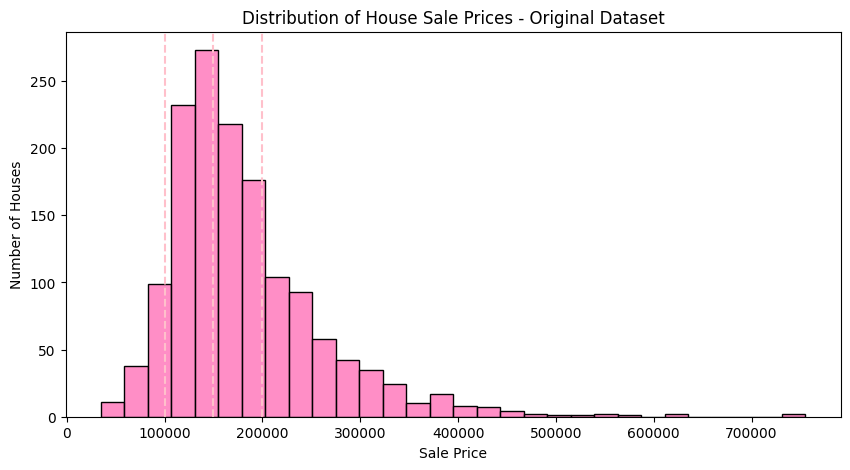

In [85]:
# Showcasing House Prices From Original Dataset As A Distribution 

plt.figure(figsize=(10,5))

sns.histplot(data=house_prices, x="SalePrice",bins=30, color="hotpink")

for cutoff in [100000, 150000, 200000]:
    plt.axvline(cutoff, linestyle="--", color="pink")

plt.title("Distribution of House Sale Prices - Original Dataset")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

### The sale-price distribution is right-skewed. Most homes are concentrated between 100,000 and 200,000, with a long upper-price tail. Using the 1.5-IQR rule, sale sale-prices above approximately $340,000 are considered potential outliers.

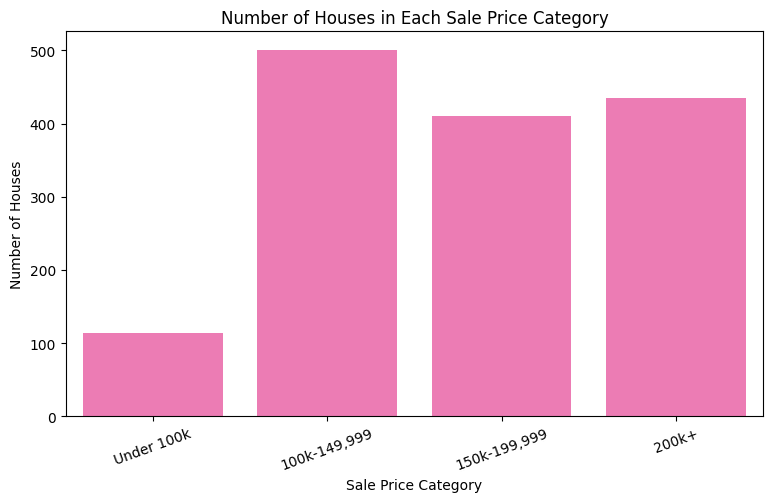

In [86]:
# Plotting New Target Price Distribution

plt.figure(figsize=(9,5))

sns.countplot(data=house_prices_data, x="SalePriceCategory",order=house_prices_labels, color="hotpink")

plt.title("Number of Houses in Each Sale Price Category")
plt.xlabel("Sale Price Category")
plt.ylabel("Number of Houses")
plt.xticks(rotation=20)
plt.show()

### This bar chart confirms that most homes fall within the 100,000 to 200,000 price range.

Value Counts: KitchenQual
KitchenQual
Ex    100
Fa     39
Gd    586
TA    735
Name: count, dtype: int64


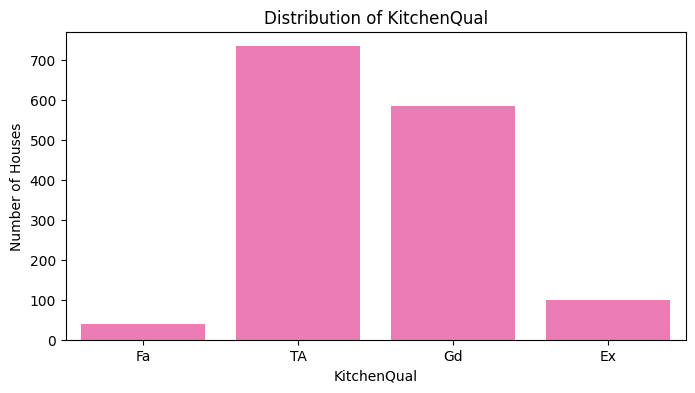

Value Counts: BedroomAbvGr
BedroomAbvGr
0      6
1     50
2    358
3    804
4    213
5     21
6      7
8      1
Name: count, dtype: int64


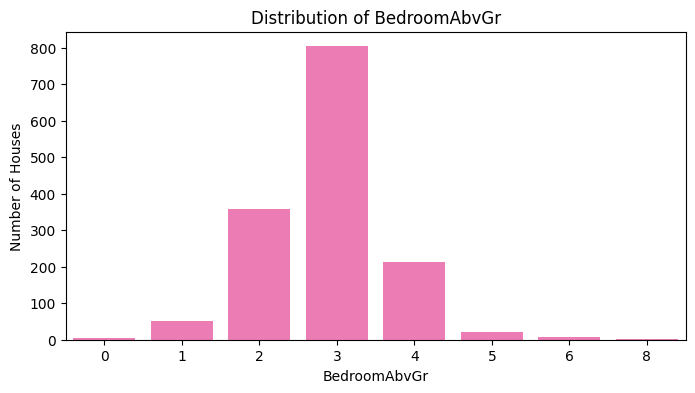

Value Counts: OverallQual
OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64


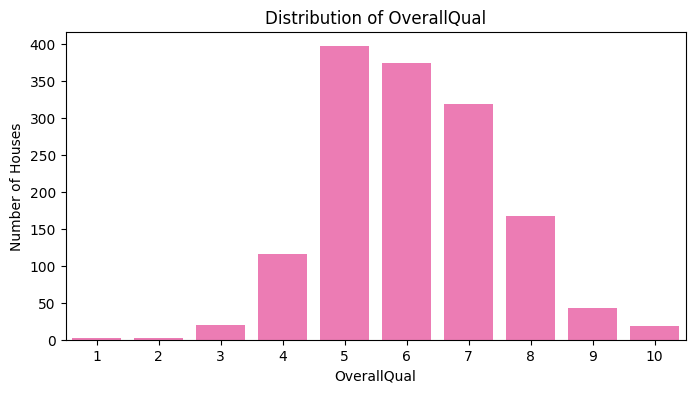

Value Counts: FullBath
FullBath
0      9
1    650
2    768
3     33
Name: count, dtype: int64


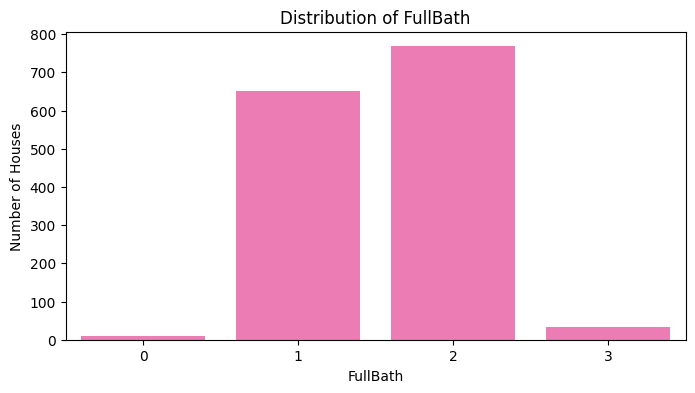

Value Counts: HalfBath
HalfBath
0    913
1    535
2     12
Name: count, dtype: int64


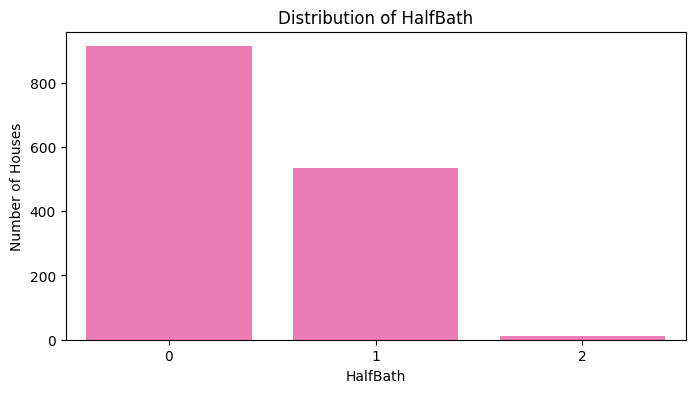

In [87]:
# Examining Discrete Predictors

discrete_predictors = ["KitchenQual","BedroomAbvGr","OverallQual","FullBath","HalfBath"]

for variable in discrete_predictors:
    print(f"Value Counts: {variable}")
    print(house_prices_data[variable].value_counts(dropna=False).sort_index())

    # Using original dataset's quality rating for KitchenQual
    if variable == "KitchenQual":
        plot_order = ["Fa", "TA","Gd","Ex"]
    else:
        plot_order = sorted(house_prices_data[variable].dropna().unique())
    
    plt.figure(figsize=(8, 4))

    sns.countplot(data=house_prices_data, x=variable, order=plot_order, color="hotpink")

    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of Houses")
    plt.show()

### Kitchen quality is concentrated in the Typical/Average and Good categories. Bedrooms above ground are centered around three bedrooms, which is close to the mean. Overall quality is concentrated at ratings 5, 6, and 7, corresponding to Average, Above Average, and Good. Most homes have one or two full bathrooms. Half-bath values are concentrated at zero and one, with relatively few homes having two half bathrooms. 

Summary Statistics: HouseAgeAtSale
count    1460.000000
mean       36.547945
std        30.250152
min         0.000000
25%         8.000000
50%        35.000000
75%        54.000000
max       136.000000
Name: HouseAgeAtSale, dtype: float64


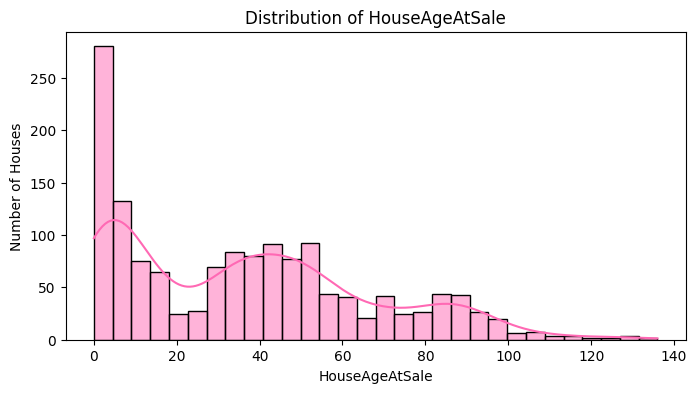

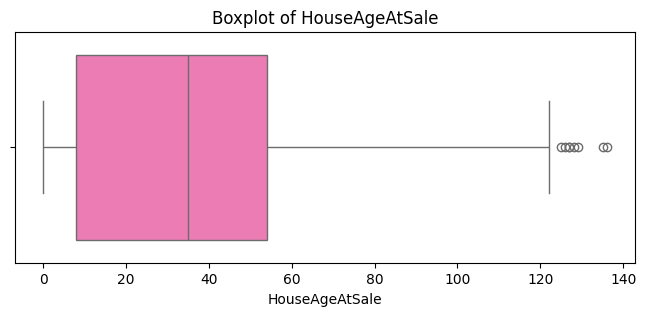

Summary Statistics: YearRemodAdd
count    1460.000000
mean     1984.865753
std        20.645407
min      1950.000000
25%      1967.000000
50%      1994.000000
75%      2004.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64


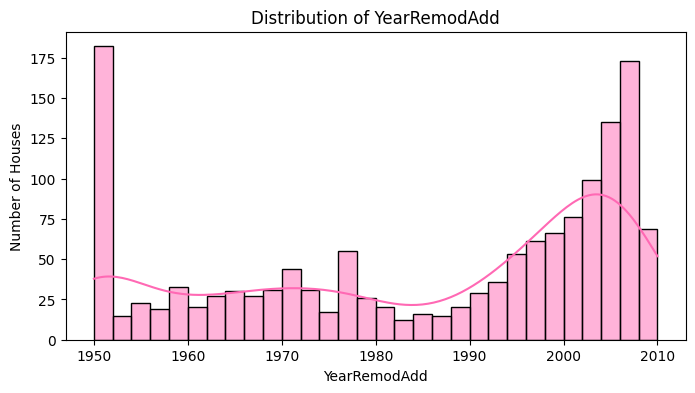

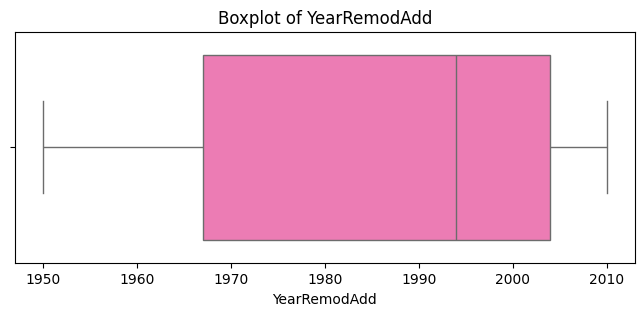

Summary Statistics: 1stFlrSF
count    1460.000000
mean     1162.626712
std       386.587738
min       334.000000
25%       882.000000
50%      1087.000000
75%      1391.250000
max      4692.000000
Name: 1stFlrSF, dtype: float64


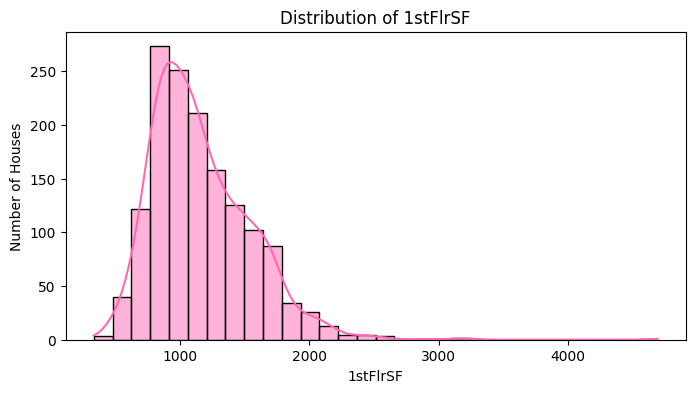

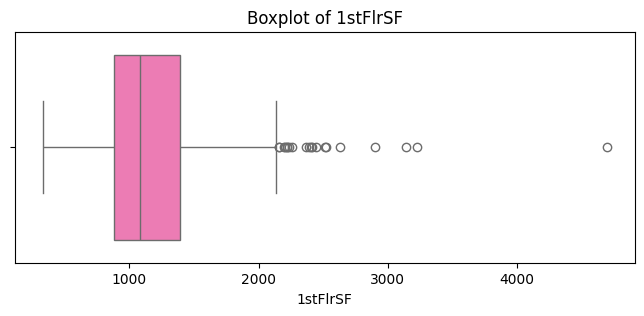

Summary Statistics: 2ndFlrSF
count    1460.000000
mean      346.992466
std       436.528436
min         0.000000
25%         0.000000
50%         0.000000
75%       728.000000
max      2065.000000
Name: 2ndFlrSF, dtype: float64


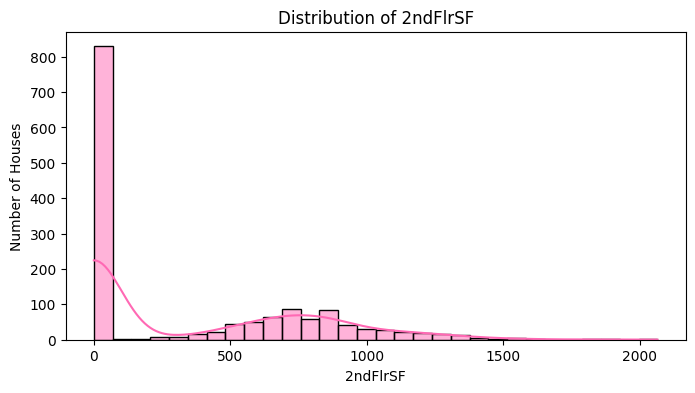

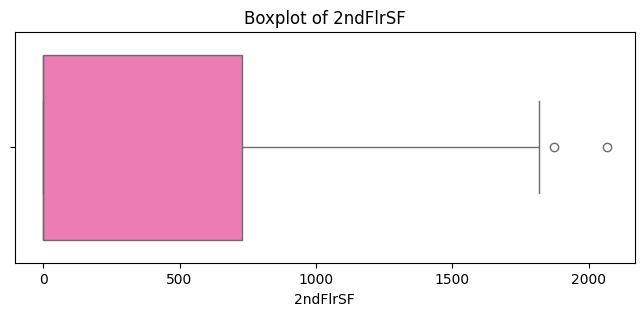

Summary Statistics: TotalBsmtSF
count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64


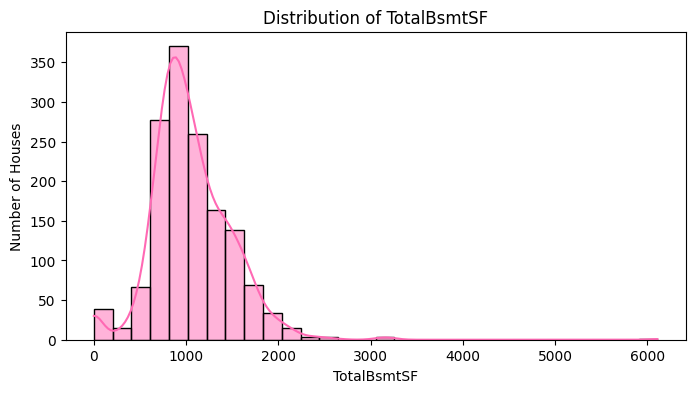

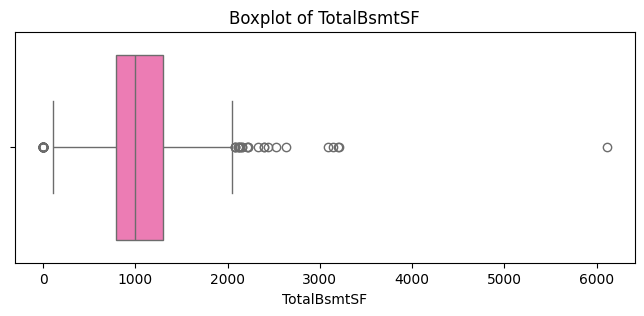

In [88]:
# Examining Continuous Predictors

continuous_predictors = ["HouseAgeAtSale","YearRemodAdd","1stFlrSF","2ndFlrSF","TotalBsmtSF"]

for variable in continuous_predictors:
    print(f"Summary Statistics: {variable}")
    print(house_prices_data[variable].describe())

    # Histogram
    plt.figure(figsize=(8, 4))

    sns.histplot(data=house_prices_data,x=variable,bins=30,kde=True,color="hotpink")

    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of Houses")
    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 3))

    sns.boxplot(data=house_prices_data,x=variable,color="hotpink")

    plt.title(f"Boxplot of {variable}")
    plt.xlabel(variable)
    plt.show()

### House Age at Sale is moderately right-skewed, with several older homes appearing as outliers. Year Remodeled shows clustering around older and more recent remodel years, with no extreme outliers in its boxplot. First-floor square footage is right-skewed and contains several high-value outliers. Second-floor square footage contains many zero values because many houses do not have a second floor; its nonzero values form a right-skewed distribution, and the boxplot identifies two outliers. Total basement square footage is right-skewed and contains several high-value outliers.

KitchenQual by Sale Price Category


SalePriceCategory,Under 100k,"100k-149,999","150k-199,999",200k+
KitchenQual,,,,
Ex,2.0,2.0,8.0,88.0
Fa,41.0,53.8,2.6,2.6
Gd,0.9,14.0,33.4,51.7
TA,12.4,53.9,27.9,5.9


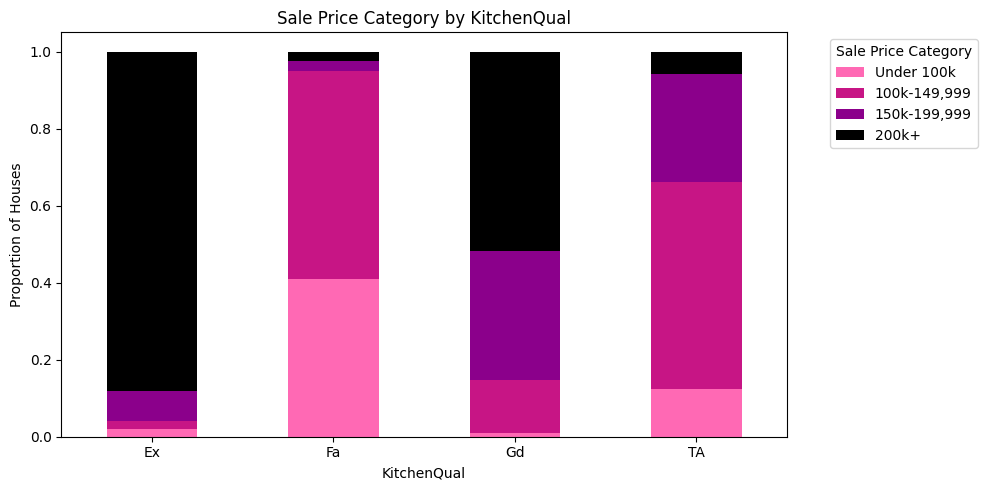

BedroomAbvGr by Sale Price Category


SalePriceCategory,Under 100k,"100k-149,999","150k-199,999",200k+
BedroomAbvGr,,,,
0,0.0,50.0,0.0,50.0
1,28.0,28.0,18.0,26.0
2,16.2,43.3,21.8,18.7
3,4.2,32.5,33.2,30.1
4,2.8,26.8,23.0,47.4
5,9.5,23.8,33.3,33.3
6,0.0,85.7,0.0,14.3
8,0.0,0.0,0.0,100.0


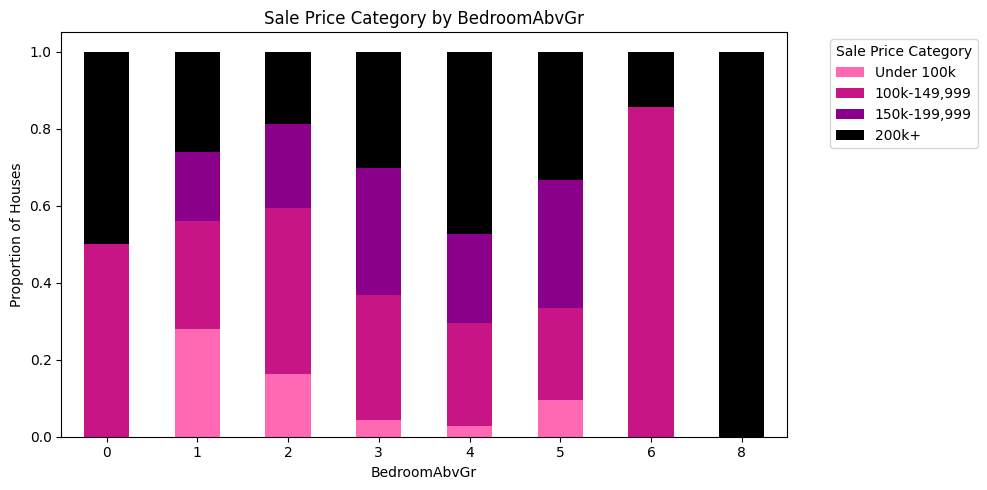

OverallQual by Sale Price Category


SalePriceCategory,Under 100k,"100k-149,999","150k-199,999",200k+
OverallQual,,,,
1,100.0,0.0,0.0,0.0
2,100.0,0.0,0.0,0.0
3,75.0,25.0,0.0,0.0
4,34.5,60.3,4.3,0.9
5,9.8,68.5,19.6,2.0
6,3.7,34.8,47.9,13.6
7,0.3,6.9,41.4,51.4
8,0.0,1.2,8.3,90.5
9,0.0,0.0,0.0,100.0


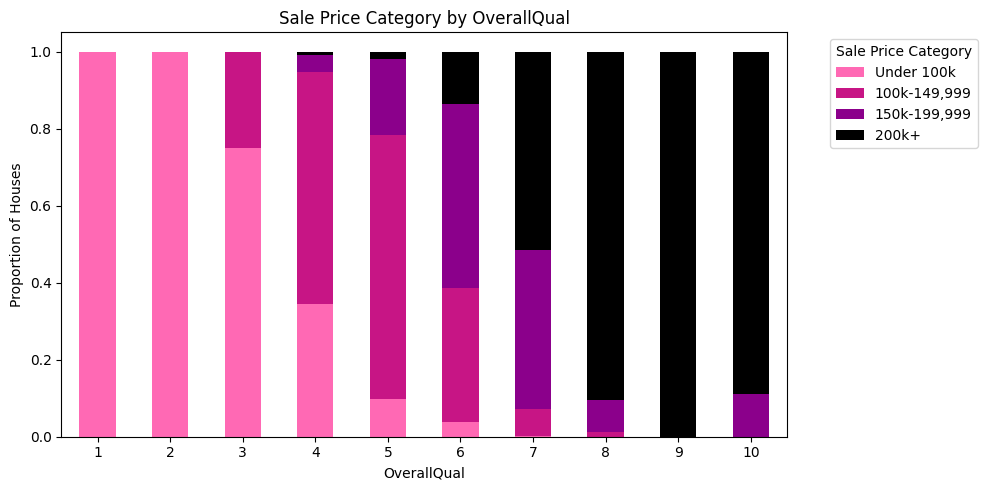

FullBath by Sale Price Category


SalePriceCategory,Under 100k,"100k-149,999","150k-199,999",200k+
FullBath,,,,
0,22.2,33.3,22.2,22.2
1,14.9,59.7,20.6,4.8
2,2.0,14.3,34.8,49.0
3,0.0,0.0,21.2,78.8


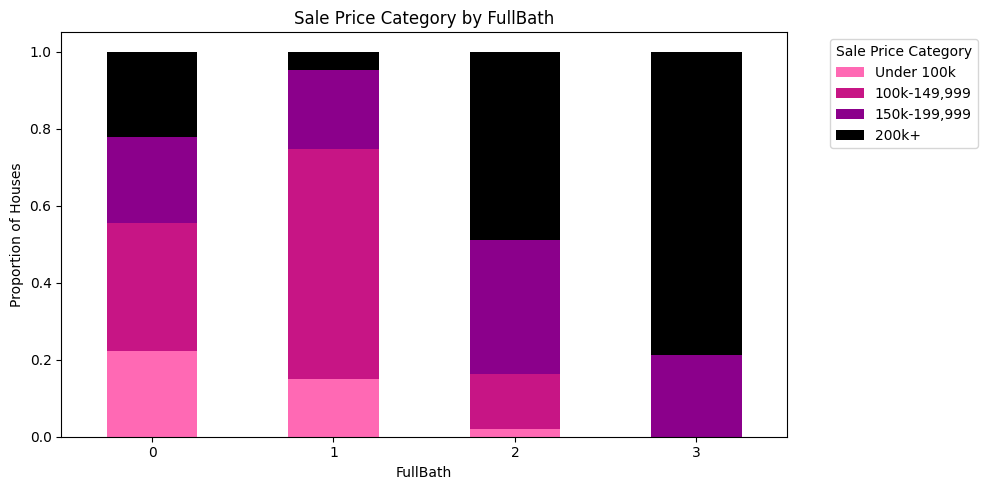

HalfBath by Sale Price Category


SalePriceCategory,Under 100k,"100k-149,999","150k-199,999",200k+
HalfBath,,,,
0,11.1,44.7,21.9,22.3
1,2.4,16.4,38.3,42.8
2,0.0,41.7,41.7,16.7


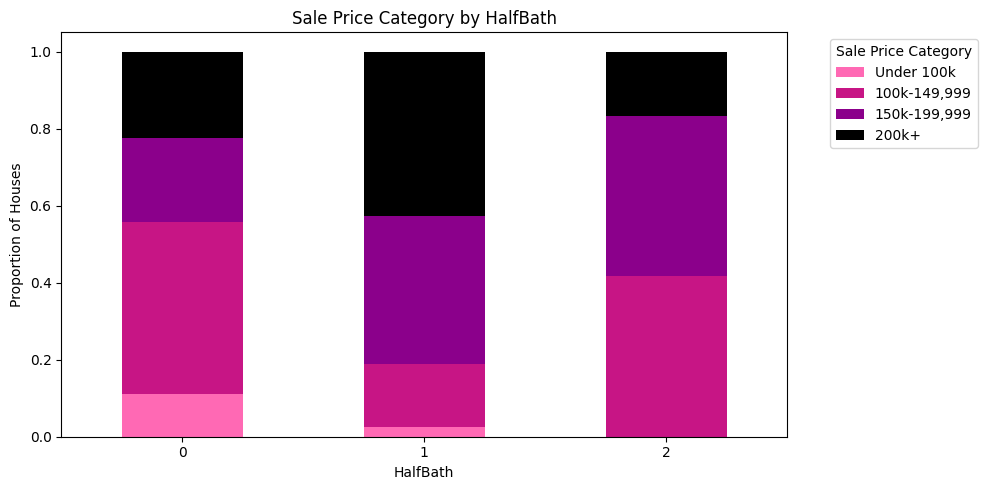

In [89]:
# Comparing Discrete Predictors With House Price Categories

category_colors = ["hotpink","mediumvioletred","darkmagenta","black"]


for variable in discrete_predictors:
    
    comparison = pd.crosstab(house_prices_data[variable],house_prices_data["SalePriceCategory"],
                             normalize="index")

    print(f"{variable} by Sale Price Category")
    display((comparison * 100).round(1))

    comparison.plot(kind="bar",stacked=True,figsize=(10, 5), color=category_colors, rot=0)

    plt.title(f"Sale Price Category by {variable}")
    plt.xlabel(variable)
    plt.ylabel("Proportion of Houses")
    
    plt.legend(title="Sale Price Category",bbox_to_anchor=(1.05,1),loc="upper left")
    
    plt.tight_layout()
    plt.show()

### Kitchen quality shows a strong relationship with sale-price category. Houses with Excellent kitchens are overwhelmingly in the 200k+ category, while houses with Fair kitchens are concentrated in the under-100k and 100k–149,999 categories. Houses with Good kitchens are most commonly in the 200k+ category, while houses with Typical/Average kitchens are most commonly in the 100k–149,999 category. The only house with eight bedrooms above ground falls in the 200k+ category; however, this is a single observation and should not be generalized. Higher overall-quality ratings, especially 8 through 10, are dominated by the 200k+ category. Homes with three full bathrooms are also concentrated in the 200k+ category. All price categories are represented across the half-bath values, although not equally.

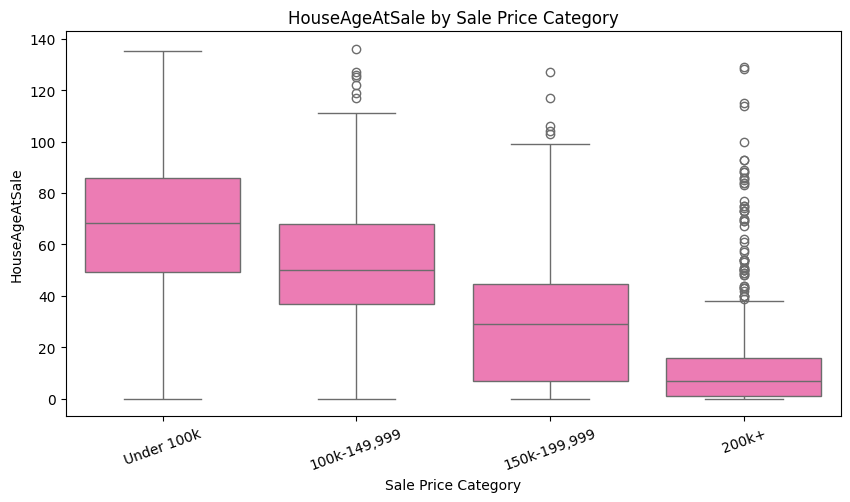

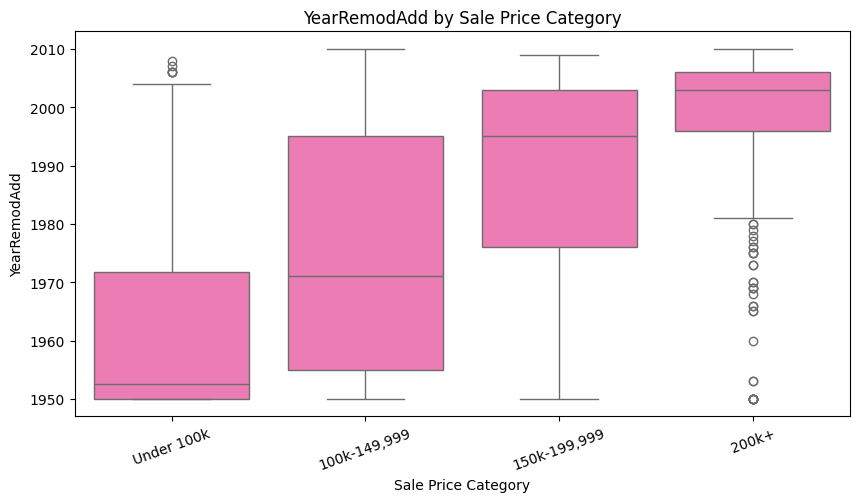

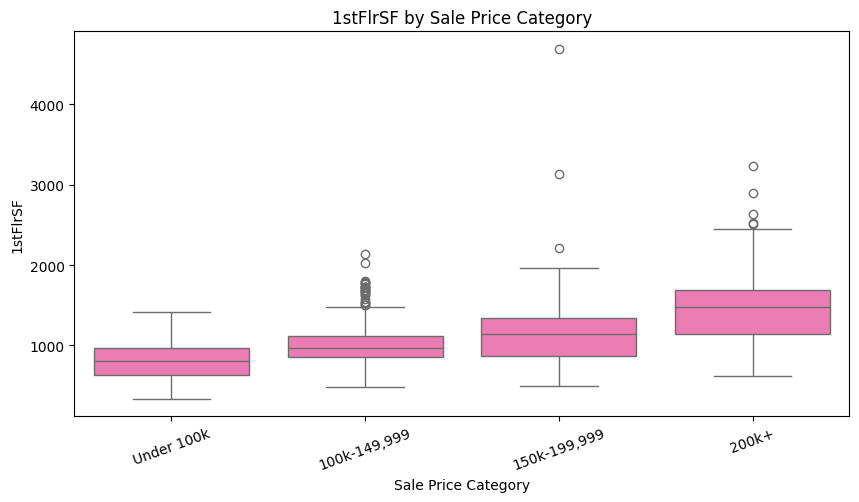

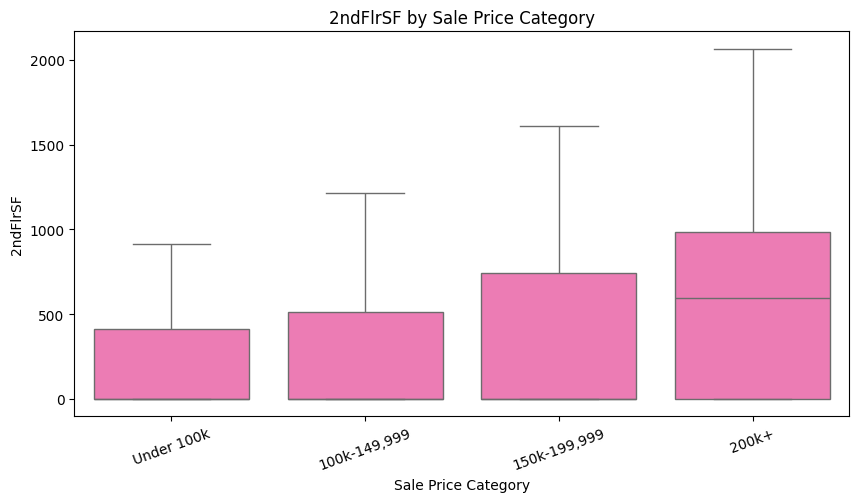

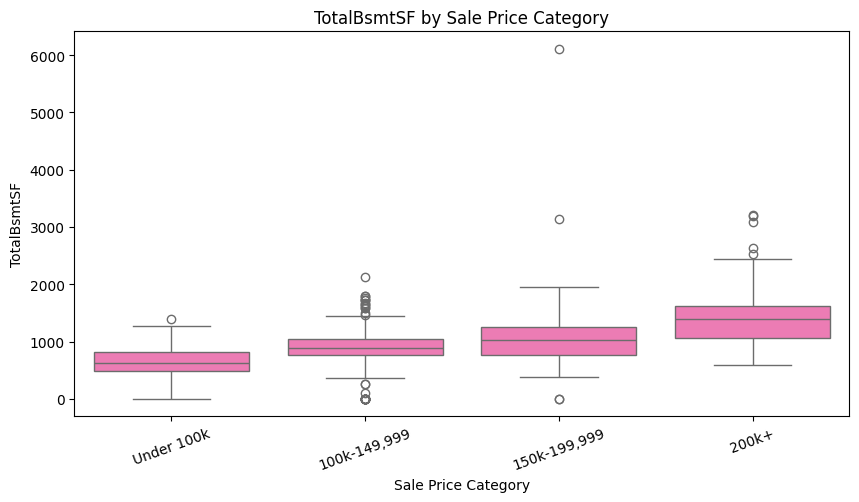

In [90]:
# Comparing Continuous Predictors with House Price Categories

for variable in continuous_predictors:
    plt.figure(figsize=(10, 5))

    sns.boxplot(data=house_prices_data,x="SalePriceCategory",y=variable,order=house_prices_labels,
               color="hotpink")

    plt.title(f"{variable} by Sale Price Category")
    plt.xlabel("Sale Price Category")
    plt.ylabel(variable)
    plt.xticks(rotation=20)
    plt.show()

### House age generally decreases as the sale-price category increases, indicating that higher-priced homes tend to be newer. Remodel years also become more recent across the higher-price categories. Median first-floor square footage, second-floor square footage, and total basement square footage generally increase with sale-price category. Several categories contain outliers, particularly for house age, first-floor area, and basement area.

In [91]:
## Encoding Kitchen Quality For Correlation Analysis

kitchen_quality_numeric = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

house_prices_data["KitchenQualNumeric"] = (house_prices_data["KitchenQual"].map(
    kitchen_quality_numeric))

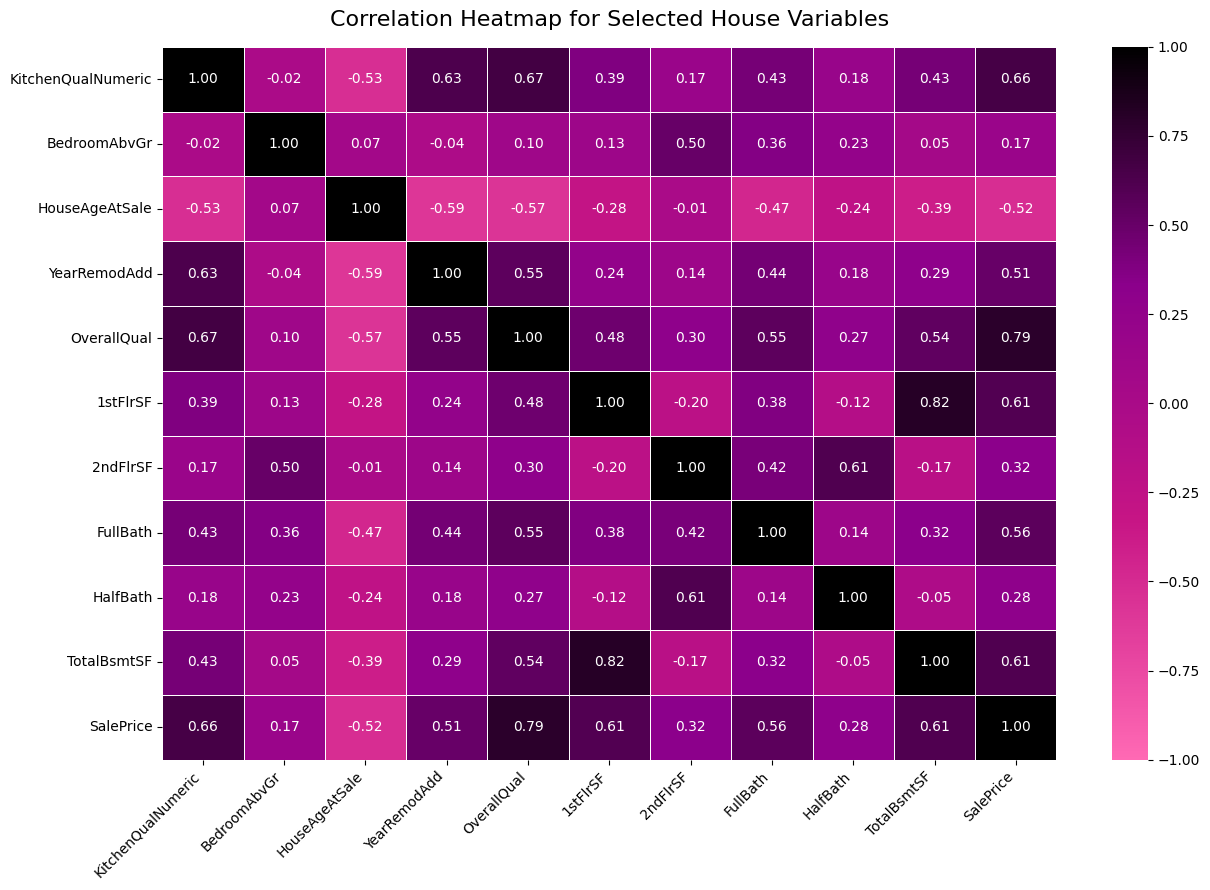

In [92]:
## Correlation Heatmap

from matplotlib.colors import LinearSegmentedColormap

correlation_columns = ["KitchenQualNumeric","BedroomAbvGr","HouseAgeAtSale","YearRemodAdd",
                       "OverallQual","1stFlrSF","2ndFlrSF","FullBath","HalfBath","TotalBsmtSF"]

# Creating a separate dataframe for correlation analysis
correlation_data = house_prices_data[correlation_columns].copy()

# Add continuous SalePrice from the original dataset
correlation_data["SalePrice"] = house_prices["SalePrice"]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

category_colors = ["hotpink","mediumvioletred","darkmagenta","black"]

custom_correlation_map = LinearSegmentedColormap.from_list("pink_purple_black",category_colors)

plt.figure(figsize=(13, 9))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap=custom_correlation_map,vmin=-1,vmax=1,linewidths=0.5,
            linecolor="white")

plt.title("Correlation Heatmap for Selected House Variables", fontsize=16,pad=15)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Overall Quality has the strongest positive correlation with Sale Price. Kitchen Quality also has a strong positive relationship with both Overall Quality and Sale Price. First-floor square footage is strongly correlated with total basement square footage, while second-floor square footage is strongly associated with half bathrooms and bedrooms above ground. House Age at Sale is negatively correlated with Year Remodeled, Overall Quality, and Sale Price, indicating that newer homes generally have newer remodel dates, higher quality ratings, and higher sale prices.

In [93]:
# Model Data

model_data = house_prices_data[["KitchenQualNumeric","BedroomAbvGr","HouseAgeAtSale","YearRemodAdd",
                                "OverallQual","1stFlrSF","2ndFlrSF","FullBath","HalfBath",
                                "TotalBsmtSF","SalePriceCategory"]].copy()

model_data.info()
model_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   KitchenQualNumeric  1460 non-null   int64   
 1   BedroomAbvGr        1460 non-null   int64   
 2   HouseAgeAtSale      1460 non-null   int64   
 3   YearRemodAdd        1460 non-null   int64   
 4   OverallQual         1460 non-null   int64   
 5   1stFlrSF            1460 non-null   int64   
 6   2ndFlrSF            1460 non-null   int64   
 7   FullBath            1460 non-null   int64   
 8   HalfBath            1460 non-null   int64   
 9   TotalBsmtSF         1460 non-null   int64   
 10  SalePriceCategory   1460 non-null   category
dtypes: category(1), int64(10)
memory usage: 115.8 KB


,KitchenQualNumeric,BedroomAbvGr,HouseAgeAtSale,YearRemodAdd,OverallQual,1stFlrSF,2ndFlrSF,FullBath,HalfBath,TotalBsmtSF,SalePriceCategory
0,4,3,5,2003,7,856,854,2,1,856,200k+
1,3,3,31,1976,6,1262,0,2,0,1262,"150k-199,999"
2,4,3,7,2002,7,920,866,2,1,920,200k+
3,4,3,91,1970,7,961,756,1,0,756,"100k-149,999"
4,4,4,8,2000,8,1145,1053,2,1,1145,200k+


In [94]:
from sklearn.model_selection import train_test_split

# Separate predictors from the categorical target
X = model_data.drop(columns="SalePriceCategory")
y = model_data["SalePriceCategory"]

# Create an 80/20 training and test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training predictor shape:", X_train.shape)
print("Test predictor shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Training predictor shape: (1168, 10)
Test predictor shape: (292, 10)
Training target shape: (1168,)
Test target shape: (292,)


### For Naive Bayes, CART, and Random Forest, use X_train, X_test, y_train, and y_test.